# Imports

In [2]:
import torch
import numpy as np
import csv
import json
import shutil
import os
import logging
from datetime import datetime
import time
from pathlib import Path

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from ase.io import read as ase_read
from ase import Atoms

from nvalchemi.data import AtomicData, Batch
from nvalchemi.data.datapipes import AtomicDataZarrReader, DataLoader, Dataset
from nvalchemi.dynamics import initialize_velocities, ZarrData
from nvalchemi.dynamics.integrators.nvt_langevin import NVTLangevin
from nvalchemi.dynamics.integrators.npt import NPT
from nvalchemi.dynamics.optimizers.fire2 import FIRE2
from nvalchemi.dynamics.base import ConvergenceHook, DynamicsStage
from nvalchemi.dynamics.hooks import (
    LoggingHook,
    SnapshotHook,
    MaxForceClampHook,
    NaNDetectorHook,
)
from nvalchemi.hooks import WrapPeriodicHook
from nvalchemi.models.aimnet2 import AIMNet2Wrapper

torch._functorch.config.donated_buffer = False
torch.set_float32_matmul_precision("high")
logging.basicConfig(level=logging.INFO)

/opt/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup params

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DT = 1.5                          # fs
FRICTION = 0.01                    # fs^-1 (= 10 ps^-1, correlation ~100 fs)
T_EQUIL = 200.0                    # K
T_MELT = 500.0                     # K
FMAX = 0.05                        # eV/A
THERMOSTAT_TIME = 100.0            # fs (NHC, literature norm for condensed phase)
BAROSTAT_TIME = 2000.0             # fs (MTK, ~20x tau_T to avoid NHC resonance)
MAX_FORCE_CLAMP = 50.0             # eV/A

P_1ATM = 101325.0 / 1.602176634e11  # eV/A^3
AMU_OVER_A3_TO_G_CM3 = 1.66054      # 1 amu/A^3 in g/cm^3

# Naphthalene: monoclinic P2_1/a (#14), Z=2
# COD 2100603: a=8.035, b=5.890, c=8.565 A, beta=123.6 deg
# 108 molecules = 54 unit cells; (3,6,3) -> ~24x35x26 A (cell vector norms)
SUPERCELL = (3, 6, 3)
TM_EXP = 353.0                     # K

# 10% durations for pipeline validation (scale up once mechanics confirmed)
THERMALIZE_PS = 5.0                # 3333 steps
EQUILIBRATE_PS = 10.0              # 6667 steps
MELT_PS = 5.0                      # 3333 steps
SLC_PS = 2.0                      # 13333 steps per temperature
SNAPSHOT_EVERY = 100               # steps
LOG_EVERY = 100                    # steps

# Change RUN_NAME per experiment. Re-running with the same RUN_NAME resumes
# from the last completed stage: each stage writes a checkpoint on exit
# and is skipped on re-entry if its checkpoint file already exists.
RUN_NAME = "naphthalene_256mol_run1"
LOG_DIR = Path("logs") / RUN_NAME
LOG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR = LOG_DIR / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)
print(f"Run {RUN_NAME} -> {LOG_DIR}, device={DEVICE}")

TEMPS = [250, 300, 350, 400, 450]

Run naphthalene_256mol_run1 -> logs/naphthalene_256mol_run1, device=cuda


In [8]:
def make_safety_hooks(model, track_stress=True):
    """Defensive MD hooks (order: neighbor -> wrap -> clamp -> NaN)."""
    extra = ["stress"] if track_stress else []
    return [
        *model.make_neighbor_hooks(),
        WrapPeriodicHook(stage=DynamicsStage.AFTER_POST_UPDATE),
        MaxForceClampHook(max_force=MAX_FORCE_CLAMP),
        NaNDetectorHook(extra_keys=extra),
    ]


class InitVelocitiesOnConverge:
    """ON_CONVERGE hook that re-initializes Maxwell-Boltzmann velocities.

    Used at the FIRE -> NVT transition in a FusedStage pipeline to replace
    FIRE's optimization-velocities with thermal velocities at T.
    """

    stage = DynamicsStage.ON_CONVERGE

    def __init__(self, temperature, seed=42):
        self.temperature = temperature
        self.seed = seed
        self.frequency = 1

    def __call__(self, ctx, stage_):
        batch = ctx.batch
        batch.velocities = torch.zeros_like(batch.positions)
        initialize_velocities(
            batch.velocities, batch.atomic_masses,
            temperature=torch.tensor([self.temperature], device=batch.positions.device),
            batch_idx=batch.batch_idx, random_seed=self.seed,
            remove_com=True, rescale=True,
        )


class StatusTransitionLogger:
    """Fused BEFORE_STEP hook that logs every batch.status transition.

    Unlike ON_CONVERGE hooks (which only fire for stages that have a
    convergence_hook), this observes batch.status directly and catches
    n_steps-based migrations (NVT -> NPT, NPT -> done) as well as
    convergence-based ones (FIRE -> NVT). Register via
    ``fused.register_fused_hook(...)``.
    """

    stage = DynamicsStage.BEFORE_STEP

    def __init__(self, labels, frequency=1):
        # labels: {status_code: human_label}
        self.labels = labels
        self.frequency = frequency
        self._prev = None
        self._t0 = time.monotonic()

    def __call__(self, ctx, stage_):
        status = ctx.batch.status.view(-1).tolist()
        if self._prev is None:
            self._prev = list(status)
            return
        elapsed = time.monotonic() - self._t0
        for prev, curr in zip(self._prev, status):
            if prev != curr:
                src = self.labels.get(prev, f"s{prev}")
                dst = self.labels.get(curr, f"s{curr}")
                logging.info("[%s->%s] graduated at step=%d  elapsed=%.2fs",
                             src, dst, ctx.step_count, elapsed)
        self._prev = list(status)

    def finalize(self, batch):
        """Flush any transition that happened on the last executed step.

        ``fused.run`` exits as soon as all systems reach exit_status, before
        the next ``BEFORE_STEP`` fires. Call this manually after the run to
        catch the final graduation (e.g. NPT->done).
        """
        if self._prev is None:
            return
        status = batch.status.view(-1).tolist()
        elapsed = time.monotonic() - self._t0
        for prev, curr in zip(self._prev, status):
            if prev != curr:
                src = self.labels.get(prev, f"s{prev}")
                dst = self.labels.get(curr, f"s{curr}")
                logging.info("[%s->%s] graduated at end of run  elapsed=%.2fs",
                             src, dst, elapsed)
        self._prev = list(status)


def batch_to_ase(batch):
    return Atoms(
        numbers=batch.atomic_numbers.cpu().numpy(),
        positions=batch.positions.detach().cpu().numpy(),
        cell=batch.cell.squeeze().detach().cpu().numpy(),
        pbc=True,
    )


def _scatter_view(ax, positions, cell, proj=(0, 1), label=""):
    """Density render of atom positions with convex-hull cell outline.

    Uses hexbin (one PolyCollection, ~gridsize^2 cells) so render cost is
    independent of atom count. The density map also distinguishes phases
    directly: dense patterned hexagons for crystal, diffuse uniform tint
    for melt.
    """
    i, j = proj
    axis_labels = ["x", "y", "z"]
    pos = positions if isinstance(positions, np.ndarray) else positions.detach().cpu().numpy()
    c = cell if isinstance(cell, np.ndarray) else cell.detach().cpu().numpy()
    ax.hexbin(pos[:, i], pos[:, j], gridsize=50, mincnt=1,
              cmap="Blues", bins="log", linewidths=0, rasterized=True)
    # Project all 8 parallelepiped vertices onto 2D, draw convex hull
    o = np.zeros(3)
    va, vb, vc = c[0], c[1], c[2]
    verts_3d = [o, va, vb, vc, va + vb, va + vc, vb + vc, va + vb + vc]
    pts = np.array([[v[i], v[j]] for v in verts_3d])
    # Deduplicate (some vertices coincide in projection)
    unique = [pts[0]]
    for p in pts[1:]:
        if not any(np.allclose(p, u, atol=0.01) for u in unique):
            unique.append(p)
    pts = np.array(unique)
    # Sort by angle from centroid to get convex hull boundary
    centroid = pts.mean(axis=0)
    angles = np.arctan2(pts[:, 1] - centroid[1], pts[:, 0] - centroid[0])
    order = np.argsort(angles)
    hull = pts[order]
    hull = np.vstack([hull, hull[0]])  # close polygon
    ax.plot(hull[:, 0], hull[:, 1], "k-", lw=0.6)
    ax.set_xlabel(f"{axis_labels[i]} (A)")
    ax.set_ylabel(f"{axis_labels[j]} (A)")
    ax.set_aspect("equal")
    if label:
        ax.set_title(label)


def visualize_structure(batch, title="", save_path=None):
    pos = batch.positions.detach().cpu().numpy()
    cell = batch.cell.squeeze().detach().cpu().numpy()
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, proj, label in zip(axes, [(0, 1), (0, 2), (1, 2)], ["xy", "xz", "yz"]):
        _scatter_view(ax, pos, cell, proj=proj, label=label)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


def load_zarr_trajectory(zarr_path, device="cpu"):
    """Load a Zarr trajectory into a list of Batch objects."""
    reader = AtomicDataZarrReader(str(zarr_path))
    ds = Dataset(reader, device=device, num_workers=1)
    try:
        loader = DataLoader(ds, batch_size=1)
        return list(loader)
    finally:
        ds.close()


def plot_trajectory_frames(source, title="", n_frames=4, save_path=None):
    """Plot evenly-spaced xy-projection frames.

    ``source`` is either a Zarr path (loaded via :func:`load_zarr_trajectory`)
    or a pre-loaded iterable of single-graph :class:`Batch` objects. The
    second form is used after :func:`extract_per_graph_trajectory` has sliced
    a multi-graph trajectory down to one system.
    """
    if isinstance(source, (str, Path)):
        frames = load_zarr_trajectory(source)
    else:
        frames = list(source)
    n_total = len(frames)
    if n_total == 0:
        print("No frames in trajectory")
        return
    indices = np.linspace(0, n_total - 1, min(n_frames, n_total), dtype=int)
    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        b = frames[idx]
        pos = b.positions.detach().cpu().numpy()
        cell = b.cell.squeeze().detach().cpu().numpy()
        _scatter_view(ax, pos, cell, proj=(0, 1), label=f"Frame {idx}/{n_total}")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


# Custom scalars for LoggingHook
def pressure_scalar(ctx):
    stress = ctx.batch.stress  # [B, 3, 3]
    return -stress.diagonal(dim1=-2, dim2=-1).mean(dim=-1)

def volume_scalar(ctx):
    return torch.linalg.det(ctx.batch.cell).abs().view(-1)

def density_scalar(ctx):
    vol = torch.linalg.det(ctx.batch.cell).abs().view(-1)
    mass_per_graph = torch.zeros(ctx.batch.num_graphs, device=vol.device)
    mass_per_graph.scatter_add_(0, ctx.batch.batch_idx, ctx.batch.atomic_masses)
    return mass_per_graph * AMU_OVER_A3_TO_G_CM3 / vol

DYNAMICS_SCALARS = {"pressure_eV_A3": pressure_scalar, "volume_A3": volume_scalar, "density_g_cm3": density_scalar}


def stdout_writer(step, rows):
    """Print log rows to stdout for Jupyter cell output."""
    for row in rows:
        parts = [f"{k}={v:.4g}" for k, v in row.items() if k not in ("graph_idx", "status")]
        print(f"  [{int(step):>6d}] {' | '.join(parts)}")


def compute_msd(snapshots, cells, n_atoms_total, ref_cell=None):
    """MSD with affine cell deformation removed.

    Each position is converted to fractional (scaled) coordinates using its
    own cell, so an atom pinned to a fixed fractional site contributes zero
    to MSD even when the cell is drifting under NPT. The accumulated
    fractional displacement is mapped back to A via ``ref_cell`` (default:
    mean cell across the window) to give a drift-neutral A^2 metric.
    """
    if ref_cell is None:
        ref_cell = torch.stack(list(cells)).mean(dim=0)
    cumulative_df = torch.zeros(n_atoms_total, 3, device=snapshots[0].device)
    msd_per_frame = []
    s_prev = snapshots[0] @ torch.linalg.inv(cells[0])
    for i in tqdm(range(1, len(snapshots)), desc="MSD frames", leave=False):
        s_i = snapshots[i] @ torch.linalg.inv(cells[i])
        df = s_i - s_prev
        df -= torch.round(df)
        cumulative_df += df
        disp_cart = cumulative_df @ ref_cell
        msd_per_frame.append((disp_cart ** 2).sum(dim=-1).cpu())
        s_prev = s_i
    return torch.stack(msd_per_frame) if msd_per_frame else torch.zeros(1, n_atoms_total)


def compute_com_msd(snapshots, cells, masses, atoms_per_mol, ref_cell=None):
    """Molecular-COM MSD with affine cell deformation removed.

    Each frame's atoms are collapsed to per-molecule mass-weighted COMs
    (PBC-unwrapped relative to the first atom of each molecule). The
    fractional-coord MSD of those COMs is then accumulated. Removes
    intramolecular vibration (C-H stretches, torsions) and molecular
    rotation (atoms moving around a pinned COM) from the signal so only
    inter-molecular translational drift contributes.

    For a stable crystal this plateaus within ~few hundred fs at
    ~0.01-0.1 A^2; a linearly growing COM MSD is the signature of genuine
    translational diffusion. The physically-meaningful D from the 3D
    Einstein relation MSD = 6 D t is fit from this curve.
    """
    if ref_cell is None:
        ref_cell = torch.stack(list(cells)).mean(dim=0)
    n_atoms = snapshots[0].shape[0]
    n_mol = n_atoms // atoms_per_mol

    com_series = []
    for snap, cell in zip(snapshots, cells):
        cell_inv = torch.linalg.inv(cell)
        mol_pos = snap.view(n_mol, atoms_per_mol, 3)
        mol_mass = masses.view(n_mol, atoms_per_mol)
        ref = mol_pos[:, 0:1, :]
        dr_frac = (mol_pos - ref) @ cell_inv
        dr_frac = dr_frac - torch.round(dr_frac)
        mol_unwrapped = ref + dr_frac @ cell
        total = mol_mass.sum(dim=-1, keepdim=True)
        com = (mol_mass.unsqueeze(-1) * mol_unwrapped).sum(dim=1) / total
        com_series.append(com)

    cumulative_df = torch.zeros(n_mol, 3, device=snapshots[0].device)
    msd_per_frame = []
    s_prev = com_series[0] @ torch.linalg.inv(cells[0])
    for i in range(1, len(com_series)):
        s_i = com_series[i] @ torch.linalg.inv(cells[i])
        df = s_i - s_prev
        df -= torch.round(df)
        cumulative_df += df
        disp_cart = cumulative_df @ ref_cell
        msd_per_frame.append((disp_cart ** 2).sum(dim=-1).cpu())
        s_prev = s_i
    return torch.stack(msd_per_frame) if msd_per_frame else torch.zeros(1, n_mol)


def compute_rdf(positions, cell, n_bins=200, r_max=10.0, chunk_size=500):
    """RDF with chunked pair computation to avoid O(N^2) memory.

    MIC wrapping is valid only when ``r_max <= min(|cell_vector|) / 2``; a
    larger ``r_max`` silently folds pair distances back on themselves and
    produces spurious g(r) tails. The guard raises before that happens.
    """
    half_min_cell = 0.5 * cell.norm(dim=-1).min().item()
    if r_max > half_min_cell:
        raise ValueError(
            f"r_max={r_max:.2f} A exceeds half the shortest cell vector "
            f"({half_min_cell:.2f} A); MIC would wrap pair distances. "
            "Reduce r_max or use a larger supercell."
        )
    n_atoms = positions.shape[0]
    vol = torch.linalg.det(cell).abs().item()
    rho = n_atoms / vol
    dr = r_max / n_bins
    r_centers = torch.linspace(dr / 2, r_max - dr / 2, n_bins, device=positions.device)
    cell_inv = torch.linalg.inv(cell)
    hist = torch.zeros(n_bins, device=positions.device)

    for start in tqdm(range(0, n_atoms, chunk_size), desc="RDF chunks", leave=False):
        end = min(start + chunk_size, n_atoms)
        chunk = positions[start:end]                       # [C, 3]
        diff = chunk.unsqueeze(1) - positions.unsqueeze(0) # [C, N, 3]
        diff_frac = diff @ cell_inv
        diff_frac -= torch.round(diff_frac)
        diff_cart = diff_frac @ cell
        dists = diff_cart.norm(dim=-1)                     # [C, N]
        # Zero self-pairs
        chunk_idx = torch.arange(end - start, device=positions.device)
        dists[chunk_idx, chunk_idx + start] = 0.0
        dists_flat = dists.reshape(-1)
        valid = dists_flat > 1e-6
        hist += torch.histc(dists_flat[valid], bins=n_bins, min=0.0, max=r_max)

    shell_vol = 4 * np.pi * r_centers ** 2 * dr
    g_r = hist / (shell_vol * rho * n_atoms)
    return r_centers.cpu().numpy(), g_r.cpu().numpy()


def _mol_inertia_eigvecs(positions, masses, atoms_per_mol, cell):
    """Per-molecule mass-weighted inertia-tensor eigenvectors.

    Unwraps each molecule via MIC relative to its first atom, builds the
    mass-weighted inertia tensor ``I = sum_i m_i (|r_i|^2 I_3 - r_i r_i^T)``
    around the molecular COM, and returns the eigenvectors sorted by
    ascending eigenvalue. Shape ``[n_mol, 3, 3]`` with ``out[m, k, :]``
    = axis k for molecule m.

    For planar elongated molecules (e.g. naphthalene) the ascending order is:
    k=0 long in-plane axis (smallest I), k=1 short in-plane axis (middle I),
    k=2 normal to molecular plane (largest I).

    Eigenvectors have ``+-`` sign ambiguity; downstream uses must be P_2
    (l=2 Legendre) or other sign-invariant forms.
    """
    n_atoms = positions.shape[0]
    assert n_atoms % atoms_per_mol == 0,         f"Atom count {n_atoms} not divisible by {atoms_per_mol}"
    n_mol = n_atoms // atoms_per_mol
    cell_inv = torch.linalg.inv(cell)
    eye3 = torch.eye(3, device=positions.device, dtype=positions.dtype)
    axes = torch.zeros(n_mol, 3, 3, device=positions.device, dtype=positions.dtype)
    for m in range(n_mol):
        sl = slice(m * atoms_per_mol, (m + 1) * atoms_per_mol)
        mol_pos = positions[sl]
        mol_mass = masses[sl].unsqueeze(-1)  # [A, 1]
        ref = mol_pos[0]
        dr = mol_pos - ref
        dr_frac = dr @ cell_inv
        dr_frac -= torch.round(dr_frac)
        mol_unwrapped = ref + dr_frac @ cell
        com = (mol_mass * mol_unwrapped).sum(dim=0) / mol_mass.sum()
        centered = mol_unwrapped - com
        r2 = (centered ** 2).sum(dim=-1, keepdim=True)
        inertia = (mol_mass * r2).sum() * eye3                   - (centered * mol_mass).T @ centered
        _, eigvecs = torch.linalg.eigh(inertia)
        # eigvecs columns ascend with eigenvalue; transpose so axes[m, k] = axis k
        axes[m] = eigvecs.T
    return axes


def compute_molecule_axes(positions, masses, atoms_per_mol, cell):
    """Return [n_mol, 3, 3] orthonormal axes per molecule, sorted by inertia.

    Builds the mass-weighted inertia tensor from PBC-unwrapped atoms for each
    molecule (MIC relative to first atom), diagonalises, and returns eigen-
    vectors with ``axes[m, 0]`` = long axis (smallest moment),
    ``axes[m, 1]`` = short / second in-plane axis,
    ``axes[m, 2]`` = normal / largest moment.

    Well-defined for anisotropic molecules (naphthalene, anthracene, ...).
    For molecules with degenerate moments (benzene, CCl4, adamantane, C60)
    the axes within a degenerate subspace are arbitrary; topology-derived
    bond vectors via RDKit / ASE bond detection are the generalisation for
    those cases -- not needed for the current naphthalene pipeline.
    """
    n_mol = positions.shape[0] // atoms_per_mol
    masses = masses.to(positions.device)
    cell = cell.to(positions.device)
    cell_inv = torch.linalg.inv(cell)
    pos = positions.view(n_mol, atoms_per_mol, 3)
    mass = masses.view(n_mol, atoms_per_mol)
    ref = pos[:, 0:1, :]
    dr_frac = (pos - ref) @ cell_inv
    dr_frac = dr_frac - torch.round(dr_frac)
    unwrapped = ref + dr_frac @ cell
    total_mass = mass.sum(dim=-1, keepdim=True)
    com = (mass.unsqueeze(-1) * unwrapped).sum(dim=1, keepdim=True) / total_mass.unsqueeze(-1)
    centered = unwrapped - com
    r2 = (centered ** 2).sum(dim=-1)
    I_trace = (mass * r2).sum(dim=-1)
    weighted = centered * mass.unsqueeze(-1)
    I_outer = torch.einsum("mai,maj->mij", weighted, centered)
    I_tensor = I_trace.view(n_mol, 1, 1) * torch.eye(3, device=positions.device) - I_outer
    _, eigvecs = torch.linalg.eigh(I_tensor)
    return eigvecs.transpose(-2, -1)


def compute_rACF(snapshots, cells, masses, atoms_per_mol, tail_frac=0.2):
    """Rank-2 (P_2) rotational autocorrelation of molecular principal axes.

    For each axis k (long, short, normal) per molecule:
        C_k(lag) = < P_2(v_k(t0) . v_k(t0 + lag)) >_(t0, mol)
    where P_2(x) = (3 x^2 - 1) / 2 is sign-invariant so the arbitrary sign
    of inertia eigenvectors doesn't matter.

    Returns a list of 3 floats (long, short, normal), each the mean of
    C_k(lag) over the last ``tail_frac`` of lags:
        1.0  = orientation perfectly preserved (crystal)
        0.0  = isotropic free rotation (liquid)

    Designed to align with the paper-standard rACF-tail S0 (Niethammer 2024;
    see analysis discussion): time-averaged, coordinate-free, distinguishes
    rotator / plastic phases from true liquids where the nematic Q cannot.
    """
    axes_series = torch.stack([
        compute_molecule_axes(snap, masses, atoms_per_mol, cell)
        for snap, cell in zip(snapshots, cells)
    ])
    n_frames = axes_series.shape[0]
    if n_frames < 2:
        return [float("nan")] * 3
    n_tail = max(1, int(n_frames * tail_frac))
    tail_lags = range(n_frames - n_tail, n_frames)
    tail_means = []
    for k in range(3):
        v = axes_series[:, :, k, :]
        vals = []
        for lag in tail_lags:
            if lag <= 0 or lag >= n_frames:
                continue
            v0 = v[: n_frames - lag]
            vt = v[lag:]
            dot = (v0 * vt).sum(dim=-1)
            p2 = 0.5 * (3 * dot ** 2 - 1)
            vals.append(p2.mean().item())
        tail_means.append(sum(vals) / len(vals) if vals else float("nan"))
    return tail_means


def compute_S0(positions, masses, atoms_per_mol, cell):
    """Mass-weighted orientational order parameter (largest eigenvalue of Q).

    Q = <(3 n n^T - I_3) / 2> is averaged over the long-axis (smallest-I)
    eigenvector of each molecule. Largest eigenvalue of Q -> 1 for aligned
    crystals, -> 0 for isotropic melts.
    """
    axes = _mol_inertia_eigvecs(positions, masses, atoms_per_mol, cell)
    long_axes = axes[:, 0, :]  # smallest eigenvalue = long axis
    n_mol = long_axes.shape[0]
    eye3 = torch.eye(3, device=positions.device, dtype=positions.dtype)
    Q = torch.zeros(3, 3, device=positions.device, dtype=positions.dtype)
    for n in long_axes:
        Q += (3 * torch.outer(n, n) - eye3) / 2
    Q /= n_mol
    return torch.linalg.eigvalsh(Q)[-1].item()


def compute_mol_axes(positions, cell, masses, atoms_per_mol):
    """Principal inertia axes per molecule, sorted by eigenvalue ascending.

    Thin wrapper over :func:`_mol_inertia_eigvecs` that preserves the legacy
    argument order ``(positions, cell, masses, atoms_per_mol)`` used by the
    rotational-ACF pipeline in the warmup diagnostics cell.
    """
    return _mol_inertia_eigvecs(positions, masses, atoms_per_mol, cell)


def compute_rotational_acf(axes_per_frame, ref_idx=0):
    """Second-rank rotational ACF C_k(t) = <P_2(v_k(t) . v_k(ref))>_mol per axis.

    P_2(x) = (3 x^2 - 1) / 2 makes this sign-flip-invariant, which is required
    because inertia-eigenvectors have no fixed sign. Paper reference:
    Yoneya & Harada (cited in the SLC melting-point paper) - the tail of this
    ACF is the rotational order parameter S0 used to classify plastic crystals.

    Args:
        axes_per_frame: list of [n_mol, 3, 3] tensors (one per frame,
            from :func:`compute_mol_axes`)
        ref_idx: frame index to use as the rotational reference

    Returns:
        np.ndarray [n_frames, 3] with one ACF curve per molecular axis
        (sorted: long, short, normal for planar elongated molecules).
    """
    ref = axes_per_frame[ref_idx]  # [n_mol, 3, 3]
    n_frames = len(axes_per_frame)
    acf = torch.zeros(n_frames, 3, device=ref.device, dtype=ref.dtype)
    for i, axes in enumerate(axes_per_frame):
        dot = (axes * ref).sum(dim=-1)      # [n_mol, 3]
        P2 = 0.5 * (3.0 * dot ** 2 - 1.0)   # [n_mol, 3]
        acf[i] = P2.mean(dim=0)
    return acf.cpu().numpy()


def compute_S0_tail(acf, tail_frac=0.2):
    """Paper-aligned S0: mean of rotational-ACF tails across 3 molecular axes.

    Phase classification (in combination with diffusion coefficient D, per
    Yoneya & Harada):
      * D ~ 0, S0 -> 1        : ordered crystal (no translation, no rotation)
      * D ~ 0, 0 < S0 < 1     : plastic crystal (no translation, hindered rotation)
      * D >> 0, S0 -> 0       : liquid (free translation and rotation)

    Args:
        acf: [n_frames, 3] rotational ACF from :func:`compute_rotational_acf`
        tail_frac: trailing fraction of frames to average as the "tail"

    Returns:
        (S0_mean, S0_per_axis) -- scalar plus per-axis tail values for
        diagnosing anisotropic hindered rotation.
    """
    n_tail = max(1, int(len(acf) * tail_frac))
    tails = acf[-n_tail:].mean(axis=0)  # [3]
    return float(tails.mean()), tails


def min_pbc_distance(positions, cell, chunk_size=500):
    """Deterministic chunked PBC min-distance over all atom pairs."""
    n = positions.shape[0]
    cell_inv = torch.linalg.inv(cell)
    global_min = float("inf")
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        chunk = positions[start:end]
        diff = chunk.unsqueeze(1) - positions.unsqueeze(0)  # [C, N, 3]
        diff_frac = diff @ cell_inv
        diff_frac -= torch.round(diff_frac)
        diff_cart = diff_frac @ cell
        dists = diff_cart.norm(dim=-1)                      # [C, N]
        # Zero self-pairs
        idx = torch.arange(end - start, device=positions.device)
        dists[idx, idx + start] = float("inf")
        chunk_min = dists.min().item()
        if chunk_min < global_min:
            global_min = chunk_min
    return global_min


def read_csv_log(path):
    with open(path) as f:
        return list(csv.DictReader(f))


def compute_density_per_graph(batch):
    """Per-graph densities in g/cm^3. Returns list[float] of length num_graphs."""
    vol = torch.linalg.det(batch.cell).abs()
    mass = torch.zeros(batch.num_graphs, device=vol.device)
    mass.scatter_add_(0, batch.batch_idx, batch.atomic_masses)
    return (mass * AMU_OVER_A3_TO_G_CM3 / vol).tolist()


def extract_per_graph_trajectory(batches, graph_idx, num_graphs):
    """Slice frames for a single graph out of a multi-graph trajectory.

    SnapshotHook + ZarrData writes each graph of a multi-graph Batch as a
    separate Zarr sample (sinks.ZarrData.write -> _count += num_graphs),
    and DataLoader(batch_size=1) yields one single-graph Batch per
    iteration. So frames for ``num_graphs`` systems are interleaved:
    ``[g0_s0, g1_s0, ..., g{M-1}_s0, g0_s1, ...]``. Recover one system's
    trajectory by striding with step=num_graphs.
    """
    return batches[graph_idx::num_graphs]


def make_graph_tagged_writer(labels):
    """Stdout writer that prefixes each row with labels[graph_idx]."""
    def writer(step, rows):
        for row in rows:
            gi = int(row.get("graph_idx", 0))
            tag = labels[gi] if gi < len(labels) else f"g{gi}"
            parts = [f"{k}={v:.4g}" for k, v in row.items()
                     if k not in ("graph_idx", "status")]
            print(f"  [{int(step):>6d}] {tag} | {' | '.join(parts)}")
    return writer


_ARRAY_KEYS = ("log_steps", "log_energies", "log_density",
               "msd_steps", "msd_crystal", "msd_melt")


def _to_jsonable(obj):
    """Recursively convert numpy/tuple containers to json-native types."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, dict):
        return {str(k): _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_jsonable(x) for x in obj]
    return obj


def _restore_arrays(analysis_d):
    """Rehydrate the time-series lists back into ndarrays in-place."""
    for a in analysis_d.values():
        for k in _ARRAY_KEYS:
            if k in a:
                a[k] = np.asarray(a[k])
    return analysis_d


# ---------------------------------------------------------------------------
# Stage-boundary checkpointing
# ---------------------------------------------------------------------------
#
# Resume model: each pipeline stage writes its own zarr/csv to LOG_DIR
# (warmup_fire.*, warmup_nvt_200k.*, warmup_npt_200k.*, melt_nvt_500k.*)
# and, on successful completion, a single-frame checkpoint at
# checkpoints/after_{stage}.zarr. Re-running with the same RUN_NAME skips
# any stage whose checkpoint already exists and loads it instead.
#
# Log files (warmup_*.zarr, warmup_*.csv, ...) are written with fresh
# mode="w" on every attempt; a crashed stage's partial log is cleanly
# overwritten when that stage reruns. The checkpoint file only appears
# after the stage's .run() returns, so checkpoint existence is the only
# unambiguous stage-complete signal.

WARMUP_STAGE_NAMES = ("fire", "nvt_200k", "npt_200k")
STATUS_BY_STAGE = {"fire": 0, "nvt_200k": 1, "npt_200k": 2}


def checkpoint_exists(stage_name, log_dir):
    return (Path(log_dir) / "checkpoints" / f"after_{stage_name}.zarr").exists()


def fresh_zarr_sink(path, capacity):
    """Return a ZarrData ready for a fresh write.

    AtomicDataZarrWriter.write() refuses to overwrite an existing store
    (FileExistsError at zarr.py:452). A stage that crashed mid-run leaves
    its log zarr on disk; the next attempt would crash on sink startup.
    Wipe the store first so every run-branch sink sees a clean slate.
    """
    path = Path(path)
    if path.exists():
        shutil.rmtree(path)
    return ZarrData(store=str(path), capacity=capacity)


def save_checkpoint(batch, stage_name, log_dir):
    """Persist `batch` (single- or multi-graph) to checkpoints/after_{stage_name}.zarr."""
    n = max(1, batch.num_graphs or 1)
    sink = fresh_zarr_sink(
        Path(log_dir) / "checkpoints" / f"after_{stage_name}.zarr",
        capacity=n,
    )
    sink.write(batch)


def load_checkpoint(stage_name, log_dir, device):
    """Load an end-of-stage Batch (single- or multi-graph) onto `device`.

    ZarrData is lazy; count samples via AtomicDataZarrReader, then poke
    `_count`/`_written_once` so `.read()` skips its empty-store guard and
    hands back a Batch with the correct num_graphs.
    """
    path = Path(log_dir) / "checkpoints" / f"after_{stage_name}.zarr"
    with AtomicDataZarrReader(str(path)) as reader:
        n = len(reader)
    sink = ZarrData(store=str(path), capacity=max(1, n))
    sink._count = n
    sink._written_once = True
    return sink.read().to(device)


def load_warmup_trajectory(log_dir, device="cpu"):
    """Concatenate per-stage warmup Zarr trajectories in FIRE -> NVT -> NPT order.

    Returns (frames, stage_labels) where stage_labels[i] is the stage key
    ("fire" / "nvt_200k" / "npt_200k") for frame i. Missing stages
    contribute no frames.
    """
    frames, labels = [], []
    for stage in WARMUP_STAGE_NAMES:
        p = Path(log_dir) / f"warmup_{stage}.zarr"
        if not p.exists():
            continue
        stage_frames = load_zarr_trajectory(p, device=device)
        frames.extend(stage_frames)
        labels.extend([stage] * len(stage_frames))
    return frames, labels


def load_warmup_csv(log_dir):
    """Concatenate per-stage warmup CSVs with cumulative step counts.

    Each per-stage CSV emits `step` starting at 0. To plot a single
    time axis we shift each stage's steps by the total steps its
    predecessors ran. The `status` column is rewritten from the
    file name so downstream code still sees FIRE=0 / NVT=1 / NPT=2
    regardless of what the hook emitted.
    """
    rows, offset = [], 0
    for stage in WARMUP_STAGE_NAMES:
        p = Path(log_dir) / f"warmup_{stage}.csv"
        if not p.exists():
            continue
        stage_rows = read_csv_log(p)
        last_step = 0
        for r in stage_rows:
            r = dict(r)
            s = int(float(r["step"]))
            r["step"] = str(s + offset)
            r["status"] = str(STATUS_BY_STAGE[stage])
            rows.append(r)
            last_step = s
        offset += last_step + LOG_EVERY
    return rows


# Read in unit cell

In [9]:
unit_cell = ase_read("data/naphthalene.cif")
ATOMS_PER_MOL = len(unit_cell) // 2  # Z=2 for naphthalene P2_1/a

a, b, c = unit_cell.cell.lengths()
alpha, beta, gamma = unit_cell.cell.angles()
print(f"Unit cell: {len(unit_cell)} atoms ({ATOMS_PER_MOL} atoms/molecule)")
print(f"Cell: a={a:.3f}, b={b:.3f}, c={c:.3f} A, beta={beta:.1f} deg")

Unit cell: 36 atoms (18 atoms/molecule)
Cell: a=8.035, b=5.890, c=8.565 A, beta=123.6 deg


# Construct supercell and create Toolkit batch

Supercell (3, 6, 3): 1944 atoms (108 molecules, 18 atoms/mol)
Cell lengths: ['24.10', '35.34', '25.69'] A
Density: 1.261 g/cm3


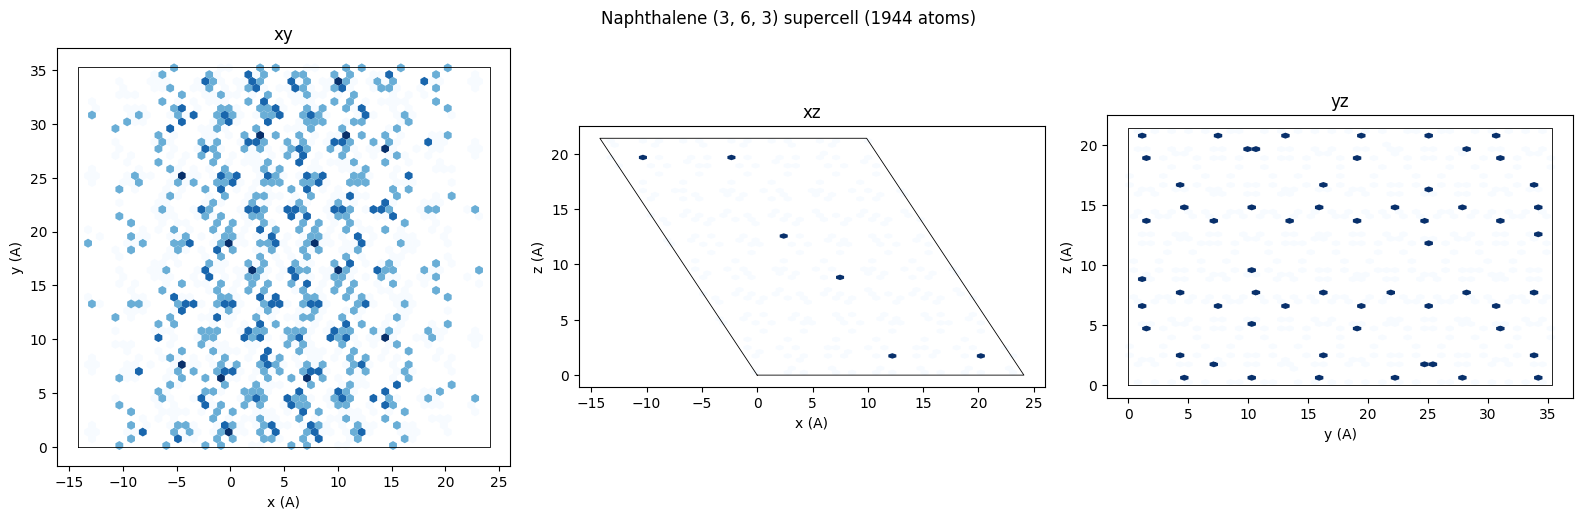

In [10]:
supercell = unit_cell * SUPERCELL
N_MOL = len(supercell) // ATOMS_PER_MOL
n = len(supercell)
print(f"Supercell {SUPERCELL}: {n} atoms ({N_MOL} molecules, {ATOMS_PER_MOL} atoms/mol)")

data = AtomicData(
    positions=torch.tensor(supercell.get_positions(), dtype=torch.float32, device=DEVICE),
    atomic_numbers=torch.tensor(supercell.get_atomic_numbers(), dtype=torch.long, device=DEVICE),
    forces=torch.zeros(n, 3, device=DEVICE),
    energy=torch.zeros(1, 1, device=DEVICE),
    stress=torch.zeros(1, 3, 3, device=DEVICE),
    cell=torch.tensor(supercell.cell.array, dtype=torch.float32, device=DEVICE).unsqueeze(0),
    pbc=torch.tensor([[True, True, True]], device=DEVICE),
)
batch = Batch.from_data_list([data], device=DEVICE)

cell_lengths = batch.cell.squeeze().norm(dim=-1)
print(f"Cell lengths: {[f'{l:.2f}' for l in cell_lengths.tolist()]} A")
print(f"Density: {compute_density_per_graph(batch)[0]:.3f} g/cm3")
assert (cell_lengths > 10.0).all(), "Cell too small for AIMNet2 cutoff"

visualize_structure(batch, title=f"Naphthalene {SUPERCELL} supercell ({n} atoms)",
                    save_path=f"{LOG_DIR}/initial_crystal.png")

# Load in AIMNet2 Model

In [11]:
aimnet2 = AIMNet2Wrapper.from_checkpoint("aimnet2", device=DEVICE, compile_model=True)
aimnet2.set_config("active_outputs", {"energy", "forces", "stress"})
print(f"AIMNet2 loaded on {DEVICE}, cutoff={aimnet2.model_config.neighbor_config.cutoff} A")
print(f"active_outputs: {sorted(aimnet2.model_config.active_outputs)}")

# Check cutoff vs cell dimensions (cutoff > cell/2 is correct but less efficient)
nc = aimnet2.model_config.neighbor_config
effective_cutoff = nc.cutoff + nc.skin
min_cell_dim = batch.cell.squeeze().norm(dim=-1).min().item()
print(f"Effective cutoff (cutoff+skin): {effective_cutoff:.2f} A, min cell dim: {min_cell_dim:.2f} A")
if effective_cutoff >= min_cell_dim / 2:
    logging.warning(
        f"Cutoff {effective_cutoff:.2f} A >= half min cell dim {min_cell_dim / 2:.2f} A. "
        "Neighbor list does redundant work."
    )

AIMNet2 loaded on cuda, cutoff=5.0 A
active_outputs: ['energy', 'forces', 'stress']
Effective cutoff (cutoff+skin): 5.00 A, min cell dim: 24.10 A


In [12]:
# Warmup: FIRE2 minimize -> NVT thermalize -> NPT equilibrate, each run as
# an independent stage with its own zarr/csv logs. On successful completion
# each stage writes a single-frame checkpoint at checkpoints/after_{stage}.zarr;
# if that file exists on re-entry, the stage is skipped and the checkpoint
# loaded instead. Crashing mid-stage leaves the per-stage log file partially
# written, which the next attempt overwrites cleanly.

n_nvt = int(THERMALIZE_PS * 1000 / DT)
n_npt = int(EQUILIBRATE_PS * 1000 / DT)
FIRE_MAX_STEPS = 5000

print(f"Warmup: FIRE2 (<={FIRE_MAX_STEPS}) -> NVT {n_nvt} -> NPT {n_npt} steps")
_warmup_t0 = time.monotonic()

# --- FIRE2 minimize ----------------------------------------------------
if checkpoint_exists("fire", LOG_DIR):
    logging.info("[FIRE] skip (checkpoint exists); loading end-of-stage batch")
    batch = load_checkpoint("fire", LOG_DIR, DEVICE)
else:
    logging.info("[FIRE] start  (budget: <=%d steps)", FIRE_MAX_STEPS)
    _t_stage = time.monotonic()
    fire_zarr = fresh_zarr_sink(
        LOG_DIR / "warmup_fire.zarr",
        capacity=FIRE_MAX_STEPS // SNAPSHOT_EVERY + 10,
    )
    fire_csv = LoggingHook(
        backend="csv", custom_scalars=DYNAMICS_SCALARS,
        log_path=str(LOG_DIR / "warmup_fire.csv"), frequency=LOG_EVERY,
    )
    fire_out = LoggingHook(
        backend="custom", writer_fn=stdout_writer,
        custom_scalars=DYNAMICS_SCALARS, frequency=LOG_EVERY,
    )
    fire_stage = FIRE2(
        model=aimnet2, dt=0.01, n_steps=FIRE_MAX_STEPS,
        convergence_hook=ConvergenceHook.from_fmax(threshold=FMAX),
        hooks=make_safety_hooks(aimnet2, track_stress=False)
              + [SnapshotHook(sink=fire_zarr, frequency=SNAPSHOT_EVERY),
                 fire_csv, fire_out],
    )
    with fire_csv, fire_out:
        batch = fire_stage.run(batch)
    save_checkpoint(batch, "fire", LOG_DIR)
    logging.info("[FIRE->NVT] stage=%.2fs  elapsed=%.2fs",
                 time.monotonic() - _t_stage, time.monotonic() - _warmup_t0)

INFO:root:[FIRE] skip (checkpoint exists); loading end-of-stage batch


Warmup: FIRE2 (<=5000) -> NVT 3333 -> NPT 6666 steps


In [13]:
# --- NVT thermalize @ T_EQUIL -----------------------------------------
if checkpoint_exists("nvt_200k", LOG_DIR):
    logging.info("[NVT 200K] skip (checkpoint exists); loading end-of-stage batch")
    batch = load_checkpoint("nvt_200k", LOG_DIR, DEVICE)
else:
    logging.info("[NVT 200K] start  (%d steps)", n_nvt)
    _t_stage = time.monotonic()
    # FIRE leaves velocities near zero; (re-)initialize Maxwell-Boltzmann at T_EQUIL.
    batch.velocities = torch.zeros_like(batch.positions)
    initialize_velocities(
        batch.velocities, batch.atomic_masses,
        temperature=torch.tensor([T_EQUIL], device=DEVICE),
        batch_idx=batch.batch_idx, random_seed=42,
        remove_com=True, rescale=True,
    )
    nvt_zarr = fresh_zarr_sink(
        LOG_DIR / "warmup_nvt_200k.zarr",
        capacity=n_nvt // SNAPSHOT_EVERY + 10,
    )
    nvt_csv = LoggingHook(
        backend="csv", custom_scalars=DYNAMICS_SCALARS,
        log_path=str(LOG_DIR / "warmup_nvt_200k.csv"), frequency=LOG_EVERY,
    )
    nvt_out = LoggingHook(
        backend="custom", writer_fn=stdout_writer,
        custom_scalars=DYNAMICS_SCALARS, frequency=LOG_EVERY,
    )
    nvt_stage = NVTLangevin(
        model=aimnet2, dt=DT, temperature=T_EQUIL, friction=FRICTION,
        n_steps=n_nvt,
        hooks=make_safety_hooks(aimnet2)
              + [SnapshotHook(sink=nvt_zarr, frequency=SNAPSHOT_EVERY),
                 nvt_csv, nvt_out],
    )
    with nvt_csv, nvt_out:
        batch = nvt_stage.run(batch)
    save_checkpoint(batch, "nvt_200k", LOG_DIR)
    logging.info("[NVT->NPT] stage=%.2fs  elapsed=%.2fs",
                 time.monotonic() - _t_stage, time.monotonic() - _warmup_t0)

INFO:root:[NVT 200K] skip (checkpoint exists); loading end-of-stage batch


INFO:root:[NPT 200K] skip (checkpoint exists); loading end-of-stage batch


Warmup done: fmax=5.4972 eV/A, density=0.911 g/cm3
Cell lengths: ['27.06', '38.29', '28.20'] A


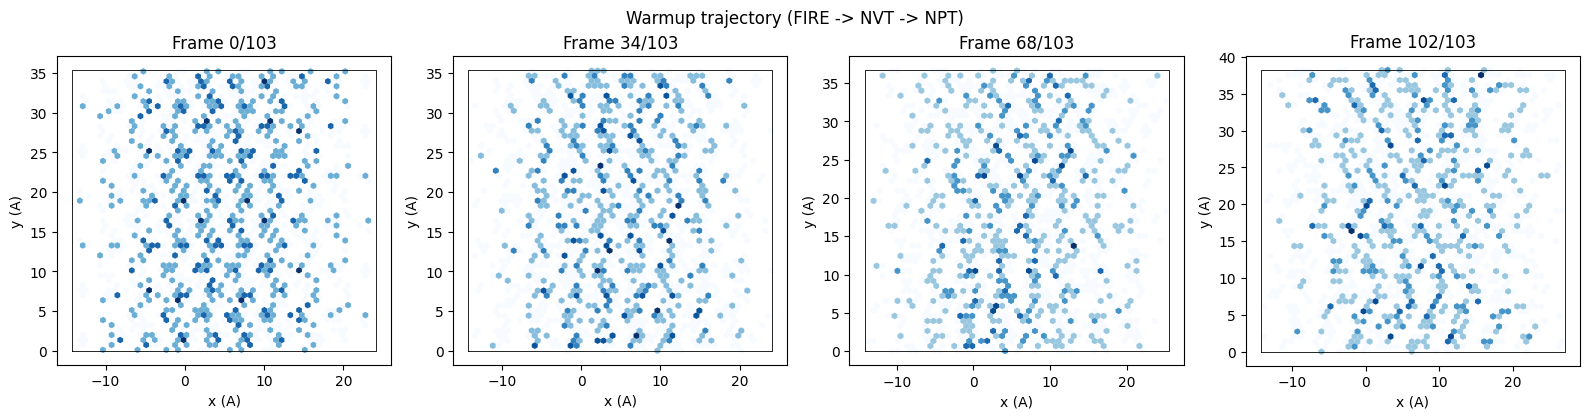

In [14]:
# --- NPT equilibrate @ T_EQUIL ----------------------------------------
if checkpoint_exists("npt_200k", LOG_DIR):
    logging.info("[NPT 200K] skip (checkpoint exists); loading end-of-stage batch")
    batch = load_checkpoint("npt_200k", LOG_DIR, DEVICE)
else:
    logging.info("[NPT 200K] start  (%d steps)", n_npt)
    _t_stage = time.monotonic()
    npt_zarr = fresh_zarr_sink(
        LOG_DIR / "warmup_npt_200k.zarr",
        capacity=n_npt // SNAPSHOT_EVERY + 10,
    )
    npt_csv = LoggingHook(
        backend="csv", custom_scalars=DYNAMICS_SCALARS,
        log_path=str(LOG_DIR / "warmup_npt_200k.csv"), frequency=LOG_EVERY,
    )
    npt_out = LoggingHook(
        backend="custom", writer_fn=stdout_writer,
        custom_scalars=DYNAMICS_SCALARS, frequency=LOG_EVERY,
    )
    npt_stage = NPT(
        model=aimnet2, dt=DT, temperature=T_EQUIL, pressure=P_1ATM,
        barostat_time=BAROSTAT_TIME, thermostat_time=THERMOSTAT_TIME,
        pressure_coupling="isotropic", n_steps=n_npt,
        hooks=make_safety_hooks(aimnet2)
              + [SnapshotHook(sink=npt_zarr, frequency=SNAPSHOT_EVERY),
                 npt_csv, npt_out],
    )
    with npt_csv, npt_out:
        batch = npt_stage.run(batch)
    save_checkpoint(batch, "npt_200k", LOG_DIR)
    logging.info("[NPT->done] stage=%.2fs  elapsed=%.2fs",
                 time.monotonic() - _t_stage, time.monotonic() - _warmup_t0)

fmax_final = batch.forces.norm(dim=-1).max().item()
density = compute_density_per_graph(batch)[0]
print(f"Warmup done: fmax={fmax_final:.4f} eV/A, density={density:.3f} g/cm3")
print(f"Cell lengths: {[f'{l:.2f}' for l in batch.cell.squeeze().norm(dim=-1).tolist()]} A")
_warmup_frames, _ = load_warmup_trajectory(LOG_DIR, device="cpu")
plot_trajectory_frames(_warmup_frames,
                       title="Warmup trajectory (FIRE -> NVT -> NPT)",
                       save_path=f"{LOG_DIR}/warmup_traj.png")

# Post warm-up analysis

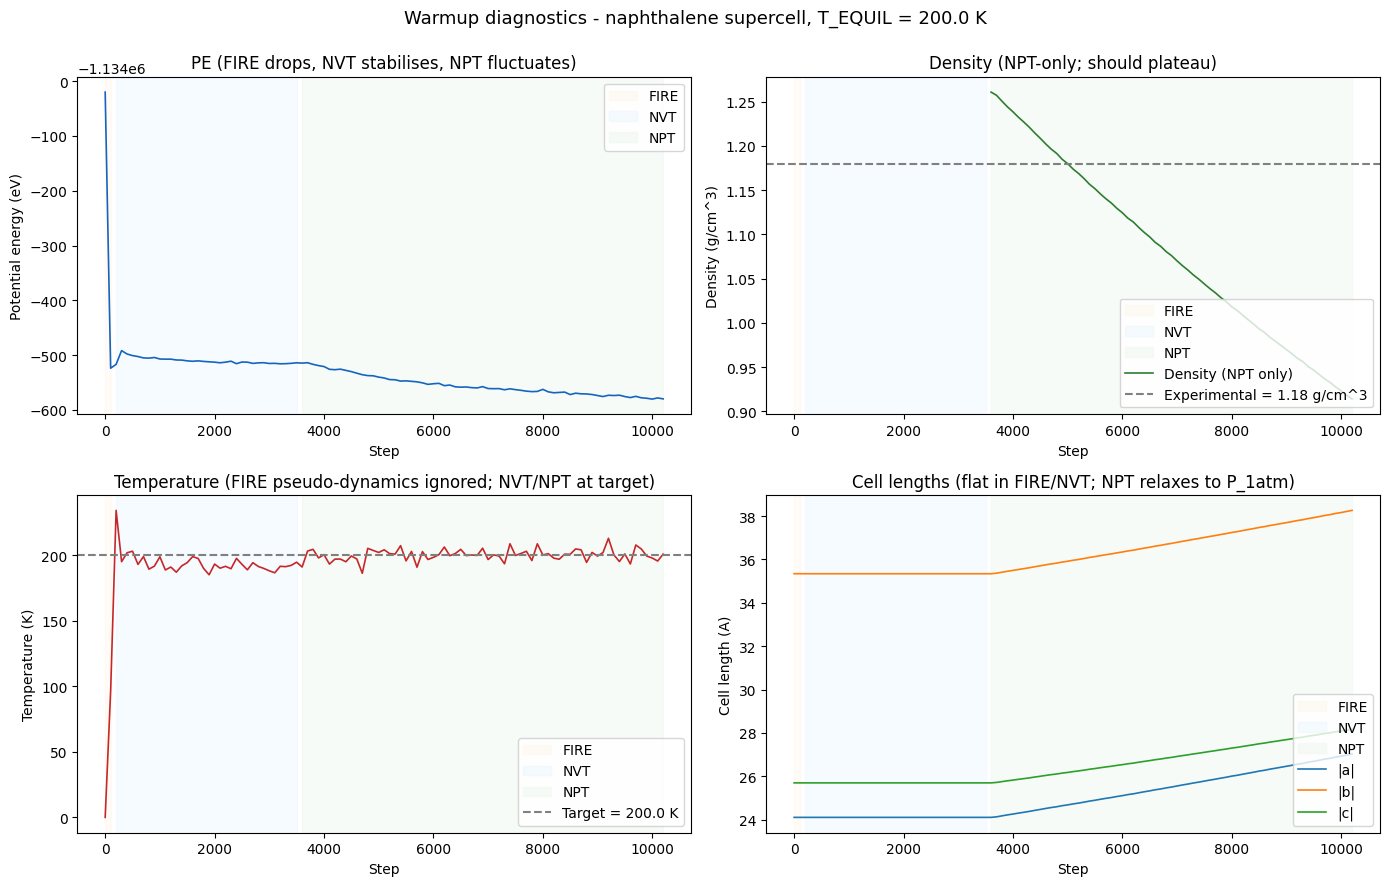

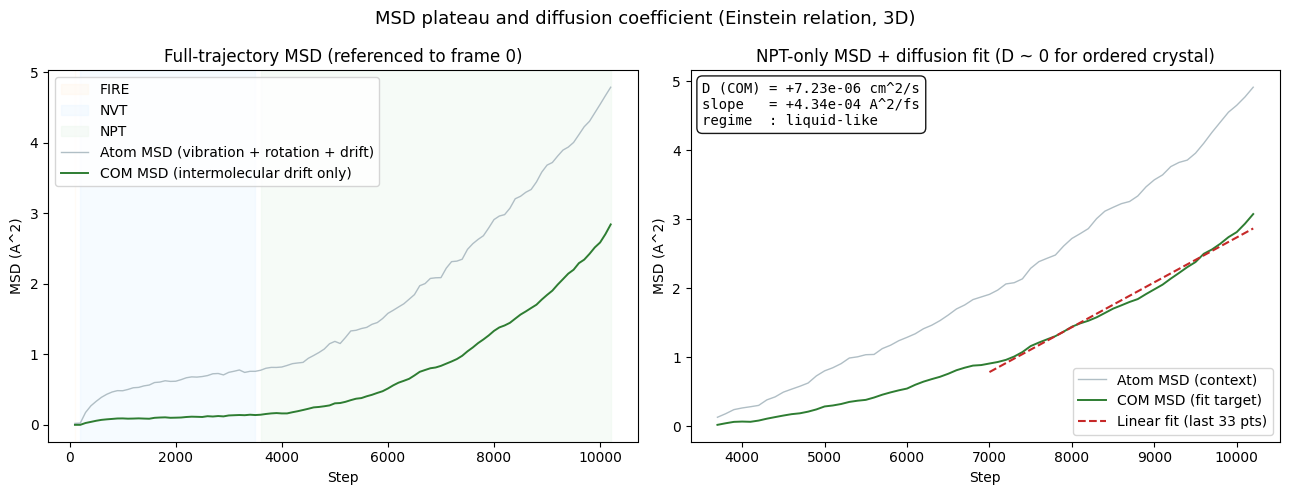

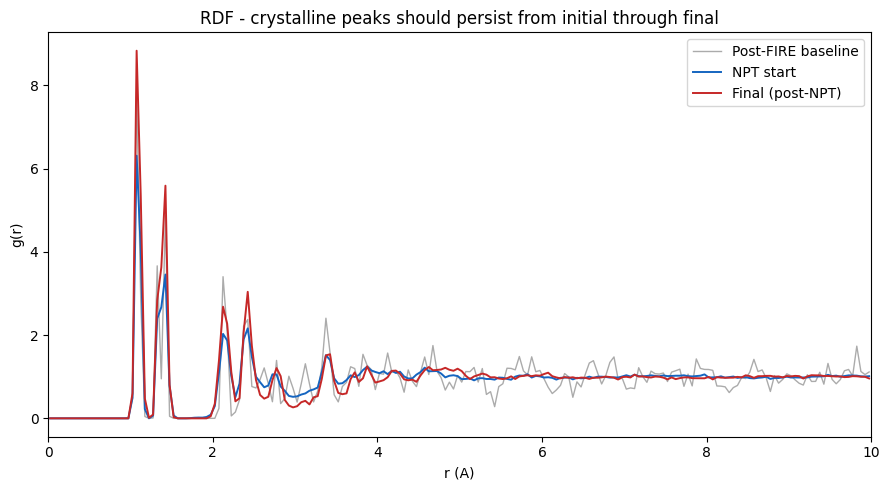

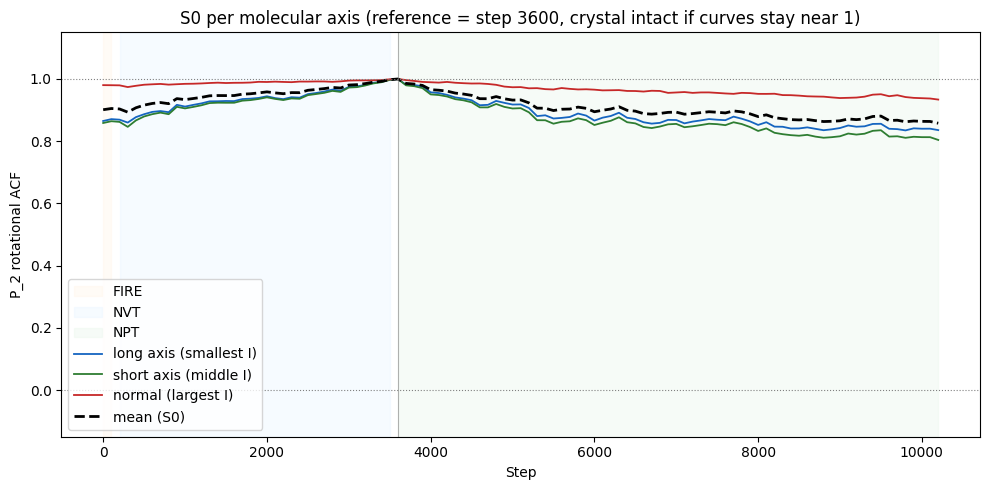

Warmup equilibration summary  [logs/naphthalene_256mol_run1]
Density (last 20% of NPT, n=13):  0.942 +/- 0.017 g/cm^3
  Experimental (298 K):                1.18 g/cm^3
  Deviation from experiment:           -20.2 %
Diffusion coefficient D:               +7.228e-06 cm^2/s
  MSD slope (A^2/fs):                  +4.337e-04
  Threshold for solid regime:          D < 1e-7 cm^2/s
Rotational order S0 (paper, NPT tail):
  per axis (long / short / normal):    +0.844  +0.818  +0.942
  mean S0:                             +0.868
  Phase: S0 -> 1 crystal, 0 < S0 < 1 plastic, S0 -> 0 liquid
Cell-length drift during NPT (A):      |da|=2.920  |db|=2.920  |dc|=2.479
Final status:                          2  (expect 3 = done)
NOTE: warmup durations are 1% of production (per cell 7c7e42da).
      This gate validates pipeline mechanics, not production-scale
      equilibration statistics. Rescale durations before trusting D.


In [15]:
# Equilibration gate for the fused warmup. Before cloning the crystal into
# the melt half we need quantitative confirmation that NPT actually converged.
# Standard molecular-crystal checks (Frenkel & Smit 2002; Yoneya & Harada):
#   (1) density plateau in NPT,
#   (2) MSD plateau -> diffusion coefficient D ~ 0 (3D Einstein: MSD = 6 D t),
#   (3) crystalline RDF peaks preserved,
#   (4) rotational order S0 -> 1 (P_2 ACF of three molecular principal axes).
# D + S0 together give the paper's plastic-crystal diagnostic:
#   D~0, S0->1 crystal;  D~0, 0<S0<1 plastic;  D>>0, S0->0 liquid.

# Per-stage warmup files are concatenated on load; see helpers cell.
log_rows = load_warmup_csv(LOG_DIR)
steps_all = np.array([int(float(r["step"])) for r in log_rows])
status_all = np.array([int(float(r["status"])) for r in log_rows])
energy_all = np.array([float(r["energy"]) for r in log_rows])
temp_all = np.array([float(r["temperature"]) for r in log_rows])
density_all = np.array([float(r["density_g_cm3"]) for r in log_rows])

warmup_frames, _stage_labels = load_warmup_trajectory(LOG_DIR, device="cpu")
snap_positions = [b.positions for b in warmup_frames]
snap_cells = [b.cell.squeeze() for b in warmup_frames]
snap_steps = np.arange(len(warmup_frames)) * SNAPSHOT_EVERY
# Stage label per snapshot comes from the filename, no CSV-step alignment needed.
snap_status = np.array([STATUS_BY_STAGE[s] for s in _stage_labels])
n_atoms = snap_positions[0].shape[0]

STAGE_COLORS = {0: "#fff4e6", 1: "#e6f4ff", 2: "#e8f5e9"}
STAGE_LABELS = {0: "FIRE", 1: "NVT", 2: "NPT"}


def shade_stages(ax, steps, status):
    """Shade FIRE/NVT/NPT regions by contiguous status runs."""
    if len(steps) == 0:
        return
    changes = np.where(np.diff(status) != 0)[0] + 1
    starts = np.concatenate(([0], changes))
    ends = np.concatenate((changes, [len(status)]))
    for s, e in zip(starts, ends):
        st = int(status[s])
        if st not in STAGE_COLORS:
            continue
        ax.axvspan(steps[s], steps[e - 1], alpha=0.35,
                   color=STAGE_COLORS[st], label=STAGE_LABELS[st], zorder=0)


def dedup_legend(ax, **kwargs):
    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, lbl in zip(handles, labels):
        seen.setdefault(lbl, h)
    ax.legend(seen.values(), seen.keys(), **kwargs)


# Cell lengths come from the Zarr trajectory (CSV logs only volume_A3).
cell_lengths_arr = np.stack([c.norm(dim=-1).cpu().numpy() for c in snap_cells])

# Figure 1: time-series diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
shade_stages(ax, steps_all, status_all)
ax.plot(steps_all, energy_all, color="#1565c0", lw=1.2)
ax.set_xlabel("Step"); ax.set_ylabel("Potential energy (eV)")
ax.set_title("PE (FIRE drops, NVT stabilises, NPT fluctuates)")
dedup_legend(ax, loc="upper right")

ax = axes[0, 1]
shade_stages(ax, steps_all, status_all)
npt_csv_mask = status_all == 2
if npt_csv_mask.any():
    ax.plot(steps_all[npt_csv_mask], density_all[npt_csv_mask],
            color="#2e7d32", lw=1.2, label="Density (NPT only)")
ax.axhline(1.18, color="gray", ls="--", label="Experimental = 1.18 g/cm^3")
ax.set_xlabel("Step"); ax.set_ylabel("Density (g/cm^3)")
ax.set_title("Density (NPT-only; should plateau)")
dedup_legend(ax, loc="lower right")

ax = axes[1, 0]
shade_stages(ax, steps_all, status_all)
ax.plot(steps_all, temp_all, color="#c62828", lw=1.2)
ax.axhline(T_EQUIL, color="gray", ls="--", label=f"Target = {T_EQUIL} K")
ax.set_xlabel("Step"); ax.set_ylabel("Temperature (K)")
ax.set_title("Temperature (FIRE pseudo-dynamics ignored; NVT/NPT at target)")
dedup_legend(ax, loc="lower right")

ax = axes[1, 1]
shade_stages(ax, snap_steps, snap_status)
for i, letter in enumerate("abc"):
    ax.plot(snap_steps, cell_lengths_arr[:, i], label=f"|{letter}|", lw=1.2)
ax.set_xlabel("Step"); ax.set_ylabel("Cell length (A)")
ax.set_title("Cell lengths (flat in FIRE/NVT; NPT relaxes to P_1atm)")
dedup_legend(ax, loc="lower right")

fig.suptitle(f"Warmup diagnostics - naphthalene supercell, T_EQUIL = {T_EQUIL} K",
             fontsize=13)
plt.tight_layout()
plt.savefig(f"{LOG_DIR}/warmup_timeseries.png", dpi=120, bbox_inches="tight")
plt.show()

# Figure 2: MSD plateau + diffusion coefficient from the NPT window.
# Einstein relation (3D): <|r(t) - r(0)|^2> = 6 D t, slope -> D via factor
# 0.1 to convert A^2/fs to cm^2/s. Two MSD curves per panel:
#   * atom MSD (light grey) -- includes intramolecular vibration + rotation,
#     present for context only;
#   * molecular-COM MSD (green) -- inter-molecular drift only, physically
#     meaningful for the diffusion coefficient and the phase regime.
# D is fit from the COM curve; atom MSD would overstate D because a rigid
# molecule at a fixed lattice site still swings its H atoms through ~0.3 A.
masses_ref = warmup_frames[0].atomic_masses
msd_full = compute_msd(snap_positions, snap_cells, n_atoms)
msd_full_mean = msd_full.mean(dim=1).numpy()
com_msd_full = compute_com_msd(snap_positions, snap_cells,
                               masses_ref, ATOMS_PER_MOL)
com_msd_full_mean = com_msd_full.mean(dim=1).numpy()
msd_full_steps = snap_steps[1:]  # compute_msd references frame 0

npt_snap_idx = np.where(snap_status == 2)[0]

npt_msd_mean = np.zeros(1)
npt_com_msd_mean = np.zeros(1)
npt_msd_steps = np.zeros(1)
fit_times_fs = np.zeros(1)
fit_msd = np.zeros(1)
slope_A2_per_fs = 0.0
intercept = 0.0
D_cm2_per_s = 0.0
n_fit = 0

if len(npt_snap_idx) >= 2:
    npt_positions = [snap_positions[i] for i in npt_snap_idx]
    npt_cells = [snap_cells[i] for i in npt_snap_idx]
    npt_msd = compute_msd(npt_positions, npt_cells, n_atoms)
    npt_msd_mean = npt_msd.mean(dim=1).numpy()
    npt_com_msd = compute_com_msd(npt_positions, npt_cells,
                                  masses_ref, ATOMS_PER_MOL)
    npt_com_msd_mean = npt_com_msd.mean(dim=1).numpy()
    npt_msd_steps = snap_steps[npt_snap_idx[1:]]

    # Fit D from the COM curve -- physically-meaningful for diffusion.
    n_fit = max(2, len(npt_msd_steps) // 2)
    fit_steps = npt_msd_steps[-n_fit:]
    fit_msd = npt_com_msd_mean[-n_fit:]
    fit_times_fs = fit_steps * DT
    slope_A2_per_fs, intercept = np.polyfit(fit_times_fs, fit_msd, 1)
    D_cm2_per_s = (slope_A2_per_fs / 6.0) * 0.1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
shade_stages(ax, msd_full_steps, snap_status[1:])
ax.plot(msd_full_steps, msd_full_mean, color="#b0bec5", lw=1.0,
        label="Atom MSD (vibration + rotation + drift)")
ax.plot(msd_full_steps, com_msd_full_mean, color="#2e7d32", lw=1.4,
        label="COM MSD (intermolecular drift only)")
ax.set_xlabel("Step"); ax.set_ylabel("MSD (A^2)")
ax.set_title("Full-trajectory MSD (referenced to frame 0)")
dedup_legend(ax, loc="upper left")

ax = axes[1]
if len(npt_snap_idx) >= 2:
    ax.plot(npt_msd_steps, npt_msd_mean, color="#b0bec5", lw=1.0,
            label="Atom MSD (context)")
    ax.plot(npt_msd_steps, npt_com_msd_mean, color="#2e7d32",
            lw=1.4, label="COM MSD (fit target)")
    fit_line = slope_A2_per_fs * fit_times_fs + intercept
    ax.plot(fit_steps, fit_line, color="#c62828", ls="--",
            lw=1.5, label=f"Linear fit (last {n_fit} pts)")
    if abs(D_cm2_per_s) < 1e-7:
        regime = "crystal (D indistinguishable from 0)"
    elif abs(D_cm2_per_s) < 1e-6:
        regime = "plastic-like"
    else:
        regime = "liquid-like"
    ax.text(0.02, 0.97,
            f"D (COM) = {D_cm2_per_s:+.2e} cm^2/s\n"
            f"slope   = {slope_A2_per_fs:+.2e} A^2/fs\n"
            f"regime  : {regime}",
            transform=ax.transAxes, va="top", fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.9))
ax.set_xlabel("Step"); ax.set_ylabel("MSD (A^2)")
ax.set_title("NPT-only MSD + diffusion fit (D ~ 0 for ordered crystal)")
ax.legend(loc="lower right")

fig.suptitle("MSD plateau and diffusion coefficient (Einstein relation, 3D)",
             fontsize=13)
plt.tight_layout()
plt.savefig(f"{LOG_DIR}/warmup_msd.png", dpi=120, bbox_inches="tight")
plt.show()

# Figure 3: RDF comparison
# Post-FIRE / pre-NVT baseline. The raw CIF snap_positions[0] sits off
# AIMNet2's energy minimum, so comparing it to post-NPT conflates
# structural relaxation with thermal / barostat effects. The first NVT
# snapshot is the AIMNet2-relaxed geometry at fixed cell and therefore
# the cleanest reference for judging subsequent RDF drift.
nvt_snap_idx = np.where(snap_status == 1)[0]
baseline_idx = int(nvt_snap_idx[0]) if len(nvt_snap_idx) else 0
rdf_baseline = compute_rdf(snap_positions[baseline_idx],
                           snap_cells[baseline_idx])
if len(npt_snap_idx) > 0:
    rdf_npt_start = compute_rdf(snap_positions[npt_snap_idx[0]],
                                snap_cells[npt_snap_idx[0]])
else:
    rdf_npt_start = rdf_baseline
rdf_final = compute_rdf(snap_positions[-1], snap_cells[-1])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rdf_baseline[0], rdf_baseline[1], color="#888888", lw=1.0,
        alpha=0.7, label="Post-FIRE baseline")
ax.plot(rdf_npt_start[0], rdf_npt_start[1], color="#1565c0", lw=1.4,
        label="NPT start")
ax.plot(rdf_final[0], rdf_final[1], color="#c62828", lw=1.4,
        label="Final (post-NPT)")
ax.set_xlim(0, 10)
ax.set_xlabel("r (A)"); ax.set_ylabel("g(r)")
ax.set_title("RDF - crystalline peaks should persist from initial through final")
ax.legend()
plt.tight_layout()
plt.savefig(f"{LOG_DIR}/warmup_rdf.png", dpi=120, bbox_inches="tight")
plt.show()

# Figure 4: Paper-aligned rotational order parameter S0 (Yoneya & Harada).
# P_2 ACF of the three molecular principal-inertia axes relative to the first
# NPT frame. For an ordered crystal at 200 K the curves should sit near 1
# throughout NPT; a decay toward 0 signals rotational disordering (melt).
# Reference is the first NPT frame, so FIRE/NVT points show "how much has the
# crystal already rotated since we entered NPT" - informational context.
masses_ref = warmup_frames[0].atomic_masses
axes_per_frame = [
    compute_mol_axes(p, c, masses_ref, ATOMS_PER_MOL)
    for p, c in zip(snap_positions, snap_cells)
]

ref_snap_idx = int(npt_snap_idx[0]) if len(npt_snap_idx) > 0 else 0
acf = compute_rotational_acf(axes_per_frame, ref_idx=ref_snap_idx)

if len(npt_snap_idx) >= 2:
    S0_mean, S0_per_axis = compute_S0_tail(acf[npt_snap_idx], tail_frac=0.2)
else:
    S0_mean = float("nan")
    S0_per_axis = np.full(3, np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
shade_stages(ax, snap_steps, snap_status)
axis_labels = ["long axis (smallest I)",
               "short axis (middle I)",
               "normal (largest I)"]
axis_colors = ["#1565c0", "#2e7d32", "#c62828"]
for k, (lbl, col) in enumerate(zip(axis_labels, axis_colors)):
    ax.plot(snap_steps, acf[:, k], lw=1.3, color=col, label=lbl)
ax.plot(snap_steps, acf.mean(axis=1), lw=2.0, color="black",
        ls="--", label="mean (S0)")
ax.axhline(1.0, color="gray", ls=":", lw=0.8)
ax.axhline(0.0, color="gray", ls=":", lw=0.8)
ax.axvline(snap_steps[ref_snap_idx], color="gray", lw=0.8, alpha=0.6)
ax.set_ylim(-0.15, 1.15)
ax.set_xlabel("Step"); ax.set_ylabel("P_2 rotational ACF")
ax.set_title(f"S0 per molecular axis (reference = step {int(snap_steps[ref_snap_idx])}, "
             "crystal intact if curves stay near 1)")
dedup_legend(ax, loc="lower left")
plt.tight_layout()
plt.savefig(f"{LOG_DIR}/warmup_S0.png", dpi=120, bbox_inches="tight")
plt.show()

# Summary stats over the last 20% of NPT for density; full NPT window for cell drift.
if npt_csv_mask.any():
    density_npt = density_all[npt_csv_mask]
    n_tail = max(1, len(density_npt) // 5)
    density_tail = density_npt[-n_tail:]
    density_mean = float(density_tail.mean())
    density_std = float(density_tail.std())
else:
    density_mean = float("nan"); density_std = float("nan"); n_tail = 0

if len(npt_snap_idx) > 0:
    npt_cell_lengths = cell_lengths_arr[npt_snap_idx]
    cell_drift = npt_cell_lengths.max(axis=0) - npt_cell_lengths.min(axis=0)
else:
    cell_drift = np.zeros(3)

final_status = int(status_all[-1]) if len(status_all) else -1

print("=" * 72)
print(f"Warmup equilibration summary  [{LOG_DIR}]")
print("=" * 72)
print(f"Density (last 20% of NPT, n={n_tail}):  {density_mean:.3f} +/- {density_std:.3f} g/cm^3")
print("  Experimental (298 K):                1.18 g/cm^3")
if not np.isnan(density_mean):
    print(f"  Deviation from experiment:           {100*(density_mean-1.18)/1.18:+.1f} %")
print(f"Diffusion coefficient D:               {D_cm2_per_s:+.3e} cm^2/s")
print(f"  MSD slope (A^2/fs):                  {slope_A2_per_fs:+.3e}")
print("  Threshold for solid regime:          D < 1e-7 cm^2/s")
print("Rotational order S0 (paper, NPT tail):")
print(f"  per axis (long / short / normal):    "
      f"{S0_per_axis[0]:+.3f}  {S0_per_axis[1]:+.3f}  {S0_per_axis[2]:+.3f}")
print(f"  mean S0:                             {S0_mean:+.3f}")
print("  Phase: S0 -> 1 crystal, 0 < S0 < 1 plastic, S0 -> 0 liquid")
print(f"Cell-length drift during NPT (A):      |da|={cell_drift[0]:.3f}  "
      f"|db|={cell_drift[1]:.3f}  |dc|={cell_drift[2]:.3f}")
print(f"Final status:                          {final_status}  (expect 3 = done)")
print("=" * 72)
print("NOTE: warmup durations are 1% of production (per cell 7c7e42da).")
print("      This gate validates pipeline mechanics, not production-scale")
print("      equilibration statistics. Rescale durations before trusting D.")


# Clone to higher temperature slab

In [ ]:
crystal_batch = batch.clone()

melt_zarr_path = Path(LOG_DIR) / "melt_nvt_500k.zarr"

if checkpoint_exists("meltgen_nvt_500k", LOG_DIR):
    logging.info("[MELT 500K] skip (checkpoint exists); loading end-of-stage batch")
    melt_batch = load_checkpoint("meltgen_nvt_500k", LOG_DIR, DEVICE)
else:
    melt_batch = batch.clone()
    initialize_velocities(
        melt_batch.velocities, melt_batch.atomic_masses,
        temperature=torch.tensor([T_MELT], device=DEVICE),
        batch_idx=melt_batch.batch_idx, random_seed=123,
        remove_com=True, rescale=True,
    )

    n_steps = int(MELT_PS * 1000 / DT)
    print(f"Melt generation: {MELT_PS} ps = {n_steps} steps at {T_MELT} K")

    zarr_sink = fresh_zarr_sink(melt_zarr_path,
                                capacity=n_steps // SNAPSHOT_EVERY + 10)
    snap_hook = SnapshotHook(sink=zarr_sink, frequency=SNAPSHOT_EVERY)

    csv_log = LoggingHook(backend="csv", custom_scalars=DYNAMICS_SCALARS,
                          log_path=str(LOG_DIR / "melt_nvt_500k.csv"),
                          frequency=LOG_EVERY)
    out_log = LoggingHook(backend="custom", writer_fn=stdout_writer,
                          custom_scalars=DYNAMICS_SCALARS, frequency=LOG_EVERY)

    nvt_melt = NVTLangevin(
        model=aimnet2, dt=DT, temperature=T_MELT, friction=FRICTION,
        n_steps=n_steps,
        hooks=make_safety_hooks(aimnet2) + [snap_hook, csv_log, out_log],
    )

    logging.info("[MELT 500K] start  (%d steps)", n_steps)
    _t_stage = time.monotonic()
    with csv_log, out_log:
        melt_batch = nvt_melt.run(melt_batch)
    save_checkpoint(melt_batch, "meltgen_nvt_500k", LOG_DIR)
    logging.info("[MELT 500K->done] stage=%.2fs", time.monotonic() - _t_stage)

# Rotational order S0 via P_2 rACF tail (paper-aligned; same metric the
# post-warmup summary reports). The snapshot nematic Q that used to live
# here is ill-defined for naphthalene P2_1/a -- the 2-sublattice herringbone
# caps nematic Q at ~0.4 even for a perfect crystal, so it can't distinguish
# crystal from melt for this compound. rACF reads each sublattice's
# orientation persistence independently: crystal -> 1, liquid -> 0.
masses_ref_cpu = crystal_batch.atomic_masses.cpu()

_warmup_frames_cpu, _stage_labels = load_warmup_trajectory(LOG_DIR, device="cpu")
_warmup_status = np.array([STATUS_BY_STAGE[s] for s in _stage_labels])
_npt_idx = np.where(_warmup_status == 2)[0]
if len(_npt_idx) >= 2:
    _npt_frames = [_warmup_frames_cpu[i] for i in _npt_idx]
    _cryst_axes = [
        compute_mol_axes(b.positions, b.cell.squeeze(), masses_ref_cpu, ATOMS_PER_MOL)
        for b in _npt_frames
    ]
    _cryst_acf = compute_rotational_acf(_cryst_axes, ref_idx=0)
    cryst_S0, _ = compute_S0_tail(_cryst_acf, tail_frac=0.2)
else:
    cryst_S0 = float("nan")

if melt_zarr_path.exists():
    _melt_frames = load_zarr_trajectory(str(melt_zarr_path), device="cpu")
    if len(_melt_frames) >= 2:
        _melt_axes = [
            compute_mol_axes(b.positions, b.cell.squeeze(), masses_ref_cpu, ATOMS_PER_MOL)
            for b in _melt_frames
        ]
        _melt_acf = compute_rotational_acf(_melt_axes, ref_idx=0)
        melt_S0, _ = compute_S0_tail(_melt_acf, tail_frac=0.2)
    else:
        melt_S0 = float("nan")
else:
    melt_S0 = float("nan")

print(f"S0 crystal={cryst_S0:.3f}, melt={melt_S0:.3f} "
      f"(rACF P_2 tail; expect melt << crystal)")
if melt_zarr_path.exists():
    plot_trajectory_frames(melt_zarr_path, title="Melt generation trajectory",
                          save_path=f"{LOG_DIR}/melt_traj.png")


INFO:root:[MELT 500K] skip (checkpoint exists); loading end-of-stage batch


# Construct combined SLC

In [ ]:
cell = crystal_batch.cell.squeeze()
c_vec = cell[2, :]

crystal_pos = crystal_batch.positions
melt_pos = melt_batch.positions + c_vec

slc_pos = torch.cat([crystal_pos, melt_pos], dim=0)
slc_Z = torch.cat([crystal_batch.atomic_numbers, melt_batch.atomic_numbers], dim=0)
slc_vel = torch.cat([crystal_batch.velocities, melt_batch.velocities], dim=0)

slc_cell = cell.clone()
slc_cell[2, :] *= 2

n_slc = slc_pos.shape[0]
slc_data = AtomicData(
    positions=slc_pos, atomic_numbers=slc_Z,
    velocities=slc_vel,
    forces=torch.zeros(n_slc, 3, device=DEVICE),
    energy=torch.zeros(1, 1, device=DEVICE),
    stress=torch.zeros(1, 3, 3, device=DEVICE),
    cell=slc_cell.unsqueeze(0),
    pbc=torch.tensor([[True, True, True]], device=DEVICE),
)
slc_batch = Batch.from_data_list([slc_data], device=DEVICE)

print(f"SLC system: {slc_batch.num_nodes} atoms")
print(f"Cell lengths: {[f'{l:.2f}' for l in slc_batch.cell.squeeze().norm(dim=-1).tolist()]} A")

In [ ]:
n_crystal = crystal_batch.num_nodes
assert slc_batch.num_nodes == 2 * n_crystal

slc_cl = slc_batch.cell.squeeze().norm(dim=-1)
cryst_cl = crystal_batch.cell.squeeze().norm(dim=-1)
assert torch.allclose(slc_cl[:2], cryst_cl[:2], atol=0.01), "a,b changed"
assert abs(slc_cl[2].item() / cryst_cl[2].item() - 2.0) < 0.01, "c not doubled"

# Deterministic PBC min-distance check (chunked, full system)
min_dist = min_pbc_distance(slc_batch.positions, slc_batch.cell.squeeze())
print(f"Min pairwise distance (PBC, all atoms): {min_dist:.2f} A")
assert min_dist > 0.5, f"Clash detected: min dist {min_dist:.2f} A"

visualize_structure(slc_batch, title=f"SLC system ({slc_batch.num_nodes} atoms)",
                    save_path=f"{LOG_DIR}/slc_construction.png")
print("All SLC checks passed")

In [ ]:
n_steps = int(SLC_PS * 1000 / DT)
print(f"Batched SLC: {len(TEMPS)} systems at {TEMPS} K, {SLC_PS} ps = {n_steps} steps each")

zarr_path = Path(LOG_DIR) / "slc_all.zarr"
csv_path = f"{LOG_DIR}/slc_all.csv"

if checkpoint_exists("slc", LOG_DIR):
    logging.info("[SLC] skip (checkpoint exists); loading end-of-stage batch")
    final_batch = load_checkpoint("slc", LOG_DIR, DEVICE)
    assert final_batch.num_graphs == len(TEMPS), (
        f"checkpoint num_graphs={final_batch.num_graphs} != len(TEMPS)={len(TEMPS)}; "
        "delete checkpoints/after_slc.zarr to rebuild"
    )
else:
    # Build a multi-graph batch: one identical SLC copy per target temperature.
    slc_data_list = []
    for _ in TEMPS:
        slc_data_list.append(AtomicData(
            positions=slc_pos.clone(),
            atomic_numbers=slc_Z.clone(),
            velocities=torch.zeros_like(slc_pos),
            forces=torch.zeros(n_slc, 3, device=DEVICE),
            energy=torch.zeros(1, 1, device=DEVICE),
            stress=torch.zeros(1, 3, 3, device=DEVICE),
            cell=slc_cell.clone().unsqueeze(0),
            pbc=torch.tensor([[True, True, True]], device=DEVICE),
        ))
    slc_multi_batch = Batch.from_data_list(slc_data_list, device=DEVICE)

    temps_tensor = torch.tensor([float(T) for T in TEMPS], device=DEVICE)
    initialize_velocities(
        slc_multi_batch.velocities, slc_multi_batch.atomic_masses,
        temperature=temps_tensor,
        batch_idx=slc_multi_batch.batch_idx,
        random_seed=42,
        remove_com=True, rescale=True,
    )

    zarr_sink = fresh_zarr_sink(zarr_path, capacity=n_steps)

    t_labels = [f"T={T}K" for T in TEMPS]
    csv_log = LoggingHook(backend="csv", custom_scalars=DYNAMICS_SCALARS,
                          log_path=csv_path, frequency=LOG_EVERY)
    out_log = LoggingHook(backend="custom", writer_fn=make_graph_tagged_writer(t_labels),
                          custom_scalars=DYNAMICS_SCALARS, frequency=LOG_EVERY)

    npt_slc = NPT(
        model=aimnet2, dt=DT, temperature=temps_tensor, pressure=P_1ATM,
        barostat_time=BAROSTAT_TIME, thermostat_time=THERMOSTAT_TIME,
        pressure_coupling="isotropic", n_steps=n_steps,
        hooks=make_safety_hooks(aimnet2)
              + [SnapshotHook(sink=zarr_sink, frequency=SNAPSHOT_EVERY),
                 csv_log, out_log],
    )

    logging.info("[SLC] start  (%d systems x %d steps)", len(TEMPS), n_steps)
    _t_stage = time.monotonic()
    with csv_log, out_log:
        final_batch = npt_slc.run(slc_multi_batch)
    save_checkpoint(final_batch, "slc", LOG_DIR)
    logging.info("[SLC->done] stage=%.2fs", time.monotonic() - _t_stage)

final_data_list = final_batch.to_data_list()
final_densities = compute_density_per_graph(final_batch)

results = {}
for i, T in enumerate(TEMPS):
    results[T] = {
        "final_batch": Batch.from_data_list([final_data_list[i]], device=DEVICE),
        "zarr_path": zarr_path,
        "log_path": csv_path,
        "graph_idx": i,
        "density": final_densities[i],
    }
    print(f"T={T}K done, density={final_densities[i]:.3f} g/cm3")

if zarr_path.exists():
    all_frames = load_zarr_trajectory(zarr_path)
    num_graphs = len(TEMPS)
    for i, T in enumerate(TEMPS):
        frames_T = extract_per_graph_trajectory(all_frames, i, num_graphs)
        plot_trajectory_frames(
            frames_T, title=f"SLC T={T}K",
            save_path=f"{LOG_DIR}/slc_T{T}K_traj.png",
        )
else:
    print(f"(skipping per-T trajectory plots: {zarr_path} not on disk)")

print(f"\nAll {len(TEMPS)} temperature points complete")


In [ ]:
n_half = slc_batch.num_nodes // 2

shared_zarr = results[TEMPS[0]]["zarr_path"]
shared_csv = results[TEMPS[0]]["log_path"]
ANALYSIS_CACHE = Path(LOG_DIR) / "analysis.json"

if ANALYSIS_CACHE.exists():
    with open(ANALYSIS_CACHE) as f:
        analysis = _restore_arrays({int(k): v for k, v in json.load(f).items()})
    print(f"Loaded cached analysis from {ANALYSIS_CACHE}")
else:
    all_frames = load_zarr_trajectory(shared_zarr, device="cpu")
    all_log = read_csv_log(shared_csv)
    analysis = {}

    for i, T in tqdm(list(enumerate(TEMPS)), desc="Analyzing T points"):
        log_data = [r for r in all_log if int(float(r["graph_idx"])) == i]
        log_steps = np.array([int(float(r["step"])) for r in log_data])
        log_energies = np.array([float(r["energy"]) for r in log_data])
        log_density = np.array([float(r["density_g_cm3"]) for r in log_data])

        traj_batches = extract_per_graph_trajectory(all_frames, i, len(TEMPS))
        snap_positions = [b.positions for b in traj_batches]
        snap_cells = [b.cell.squeeze() for b in traj_batches]

        # Full-trajectory MSD w.r.t. frame 0 of the SLC run.
        # Crystal half: plateau -> stable solid; linear growth -> melting.
        # Melt half: linear growth under diffusion (always).
        if len(snap_positions) > 1:
            msd_data = compute_msd(snap_positions, snap_cells, slc_batch.num_nodes)
            msd_crystal_series = msd_data[:, :n_half].mean(dim=1).numpy()
            msd_melt_series = msd_data[:, n_half:].mean(dim=1).numpy()
            # compute_msd skips frame 0 (reference), so MSD[k] -> step (k+1)*SNAPSHOT_EVERY.
            msd_steps = np.arange(1, len(snap_positions)) * SNAPSHOT_EVERY
        else:
            msd_crystal_series = msd_melt_series = np.zeros(1)
            msd_steps = np.zeros(1)

        final_pos = results[T]["final_batch"].positions
        final_cell = results[T]["final_batch"].cell.squeeze()
        final_masses = results[T]["final_batch"].atomic_masses

        # Primary: rACF-tail S0 (time-averaged P_2 correlation per principal
        # axis). Aligns with Niethammer 2024 SLC methodology; distinguishes
        # plastic / rotator phases from true liquids. Axes ordered long /
        # short / normal from the mass-weighted inertia tensor.
        crystal_pos_traj = [p[:n_half] for p in snap_positions]
        melt_pos_traj = [p[n_half:] for p in snap_positions]
        masses_half = final_masses[:n_half]
        rACF_crystal = compute_rACF(crystal_pos_traj, snap_cells, masses_half, ATOMS_PER_MOL)
        rACF_melt = compute_rACF(melt_pos_traj, snap_cells, masses_half, ATOMS_PER_MOL)
        S0_crystal = sum(rACF_crystal) / 3.0
        S0_melt = sum(rACF_melt) / 3.0

        # Secondary: instantaneous nematic Q eigenvalue on the final frame.
        # Only meaningful for elongated molecules; kept as a cross-check.
        nemQ_crystal = compute_S0(final_pos[:n_half], masses_half, ATOMS_PER_MOL, final_cell)
        nemQ_melt = compute_S0(final_pos[n_half:], final_masses[n_half:], ATOMS_PER_MOL, final_cell)

        analysis[T] = {
            "log_steps": log_steps,
            "log_energies": log_energies,
            "log_density": log_density,
            "msd_steps": msd_steps,
            "msd_crystal": msd_crystal_series,
            "msd_melt": msd_melt_series,
            "density_final": results[T]["density"],
            "msd_crystal_final": float(msd_crystal_series[-1]) if len(msd_crystal_series) else 0.0,
            "msd_melt_final": float(msd_melt_series[-1]) if len(msd_melt_series) else 0.0,
            "S0_crystal": S0_crystal, "S0_melt": S0_melt,
            "S0_crystal_axes": rACF_crystal, "S0_melt_axes": rACF_melt,
            "nemQ_crystal": nemQ_crystal, "nemQ_melt": nemQ_melt,
        }

    with open(ANALYSIS_CACHE, "w") as f:
        json.dump(_to_jsonable(analysis), f, indent=1)
    print(f"Saved analysis to {ANALYSIS_CACHE}")

print(f"{'T (K)':>8} {'Density':>10} {'MSD_cryst':>10} {'MSD_melt':>10} {'S0_cryst':>10} {'S0_melt':>10} {'nemQ_cr':>10} {'nemQ_mt':>10}")
print("-" * 90)
for T in TEMPS:
    a = analysis[T]
    print(f"{T:8d} {a['density_final']:10.3f} {a['msd_crystal_final']:10.2f} "
          f"{a['msd_melt_final']:10.2f} {a['S0_crystal']:10.3f} {a['S0_melt']:10.3f} "
          f"{a.get('nemQ_crystal', float('nan')):10.3f} {a.get('nemQ_melt', float('nan')):10.3f}")


In [ ]:
# Figure 1: time-series diagnostics over the SLC run.
# Near Tm the solid-liquid interface is stationary -> PE, density, and
# crystal-half MSD all plateau. Below Tm the liquid freezes (PE drops,
# density rises, melt MSD plateau grows toward cryst baseline). Above Tm
# the solid melts (PE rises, density drops, crystal MSD transitions to
# linear growth like the melt).
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for T in TEMPS:
    a = analysis[T]
    ax.plot(a["log_steps"], a["log_energies"], label=f"{T} K")
ax.set_xlabel("Step"); ax.set_ylabel("Potential energy (eV)")
ax.set_title("Potential energy (plateau slope -> 0 at Tm)")
ax.legend()

ax = axes[0, 1]
for T in TEMPS:
    a = analysis[T]
    ax.plot(a["log_steps"], a["log_density"], label=f"{T} K")
ax.set_xlabel("Step"); ax.set_ylabel("Density (g/cm^3)")
ax.set_title("Density (rise -> freezing, drop -> melting)")
ax.legend()

ax = axes[1, 0]
for T in TEMPS:
    a = analysis[T]
    ax.plot(a["msd_steps"], a["msd_crystal"], label=f"{T} K")
ax.set_xlabel("Step"); ax.set_ylabel("MSD (A^2)")
ax.set_title("Crystal half MSD (plateau < 2 A^2 -> solid)")
ax.legend()

ax = axes[1, 1]
for T in TEMPS:
    a = analysis[T]
    ax.plot(a["msd_steps"], a["msd_melt"], label=f"{T} K")
ax.set_xlabel("Step"); ax.set_ylabel("MSD (A^2)")
ax.set_title("Melt half MSD (linear growth -> liquid)")
ax.legend()

fig.suptitle(f"SLC time-series diagnostics - Naphthalene (Tm_exp = {TM_EXP} K)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{LOG_DIR}/slc_timeseries.png", dpi=120, bbox_inches="tight")
plt.show()

# Figure 2: endpoint summary (final values vs T).
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(TEMPS, [analysis[T]["density_final"] for T in TEMPS], "o-", markersize=8)
ax.axvline(TM_EXP, color="gray", ls="--", label=f"Tm_exp = {TM_EXP} K")
ax.set_xlabel("Temperature (K)"); ax.set_ylabel("Density (g/cm^3)")
ax.set_title("Final density")
ax.legend()

ax = axes[1]
ax.plot(TEMPS, [analysis[T]["msd_crystal_final"] for T in TEMPS], "s-", label="Crystal half")
ax.plot(TEMPS, [analysis[T]["msd_melt_final"] for T in TEMPS], "o-", label="Melt half")
ax.axvline(TM_EXP, color="gray", ls="--")
ax.set_xlabel("Temperature (K)"); ax.set_ylabel("Final MSD (A^2)")
ax.set_title("Final MSD (cryst diverges above Tm)")
ax.legend()

ax = axes[2]
ax.plot(TEMPS, [analysis[T]["S0_crystal"] for T in TEMPS], "s-", label="Crystal half")
ax.plot(TEMPS, [analysis[T]["S0_melt"] for T in TEMPS], "o-", label="Melt half")
ax.axvline(TM_EXP, color="gray", ls="--")
ax.set_xlabel("Temperature (K)"); ax.set_ylabel("S0")
ax.set_title("Rotational order parameter")
ax.legend()

fig.suptitle(f"SLC endpoint summary - Naphthalene (Tm_exp = {TM_EXP} K)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{LOG_DIR}/slc_endpoints.png", dpi=120, bbox_inches="tight")
plt.show()

# Phase-resolved g(r) at low / near-Tm / high T.
# SLC keeps the interface stationary at Tm, so the crystal half retains its
# long-range peaks at T <= Tm and loses them above Tm; the melt half stays
# liquid-like unless it recrystallises onto the interface at T << Tm.
rdf_temps = [TEMPS[0], TEMPS[len(TEMPS) // 2], TEMPS[-1]]
rdf_finals = {}
for T in rdf_temps:
    pos = results[T]["final_batch"].positions
    cell_t = results[T]["final_batch"].cell.squeeze()
    rdf_finals[T] = {
        "crystal": compute_rdf(pos[:n_half], cell_t),
        "melt": compute_rdf(pos[n_half:], cell_t),
    }

fig, axes = plt.subplots(1, len(rdf_temps), figsize=(6 * len(rdf_temps), 5))
for ax, T in zip(axes, rdf_temps):
    r_c, gr_c = rdf_finals[T]["crystal"]
    r_m, gr_m = rdf_finals[T]["melt"]
    ax.plot(r_c, gr_c, label="Crystal half")
    ax.plot(r_m, gr_m, label="Melt half", ls="--")
    ax.set_xlabel("r (A)"); ax.set_ylabel("g(r)"); ax.set_title(f"RDF at T = {T} K")
    ax.set_xlim(0, 10)
    ax.legend()
plt.tight_layout()
plt.savefig(f"{LOG_DIR}/slc_rdf.png", dpi=120, bbox_inches="tight")
plt.show()

# Before/after g(r): initial SLC (t=0) vs. final at the three rdf_temps.
# Crystal-half initial is fully crystalline; melt-half initial is already
# liquid-like (pre-equilibrated at T_MELT in the melt-generation step).
# Overlaying finals against those baselines shows how far each T drifts
# from its starting structure over the SLC run.
init_cell = slc_batch.cell.squeeze()
r_c0, gr_c0 = compute_rdf(slc_batch.positions[:n_half], init_cell)
r_m0, gr_m0 = compute_rdf(slc_batch.positions[n_half:], init_cell)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.get_cmap("viridis")
colors = [cmap(x) for x in np.linspace(0.15, 0.85, len(rdf_temps))]
for ax, half in zip(axes, ["crystal", "melt"]):
    r0, gr0 = (r_c0, gr_c0) if half == "crystal" else (r_m0, gr_m0)
    ax.plot(r0, gr0, color="k", lw=1.5, label="Initial (t = 0)")
    for T, color in zip(rdf_temps, colors):
        r, gr = rdf_finals[T][half]
        ax.plot(r, gr, color=color, ls="--", label=f"Final, T = {T} K")
    ax.set_xlabel("r (A)"); ax.set_ylabel("g(r)")
    ax.set_title(f"{half.capitalize()} half: initial vs. final")
    ax.set_xlim(0, 10)
    ax.legend()
plt.tight_layout()
plt.savefig(f"{LOG_DIR}/slc_rdf_evolution.png", dpi=120, bbox_inches="tight")
plt.show()
